### CrewAI vs LangGraph

|Features|LangGraph|CrewAI|
|---|---|---|
|**Mental Model**|**State Machines**: You think in terms of nodes (functions) and edges (transitions).|**Corporate Team**: You think in terms of Roles, Goals, and Backstories (Manager, Researcher, etc.).|
|**Control**|**High**: You define exactly when and where the "ball" is passed.|**Moderate**: You define the team; the framework handles the "how" of the collaboration.|
|**Best for**|Complex, looping workflows and production reliability.|Rapid prototyping and intuitive multi-agent collaboration.|

## Design AI Agent WOrkflows with CrewAI

### Objectives
- **core components** of CrewAI
- **agents** and **tasks** work toughter
- How CrewAI handles the **sequential task** execution
- how to access the resut and evalaute usage metrics using the **CrewOutput** object

- CrewAI
    -  designed on role-based multi-agent collaboration
    -  4 main components
        - tasks
        - agents
        - tools
        - flow

    - Task
        - like a director, and have clear vision (what need to be achieved?)
        - task can be defined by 2 key parameters
            - **Goal** and the **Agent**
        
        - Description
            - it is what you wnat your AI agent to do
            - Analogy: "Make an eye-catching commercial that will sell our car."

        - Expected output
            - It defines sepecific requirements
                - Example:"Make it a 30-second car commercial"
            - May include variable parameters
                - Example:"Make a 20 second commercial about boats."
        - Agents
            - powered by an LLM
            - Defined with structured prompts
            - Provide more personality than other frameworks

        - Agent structured prompt
        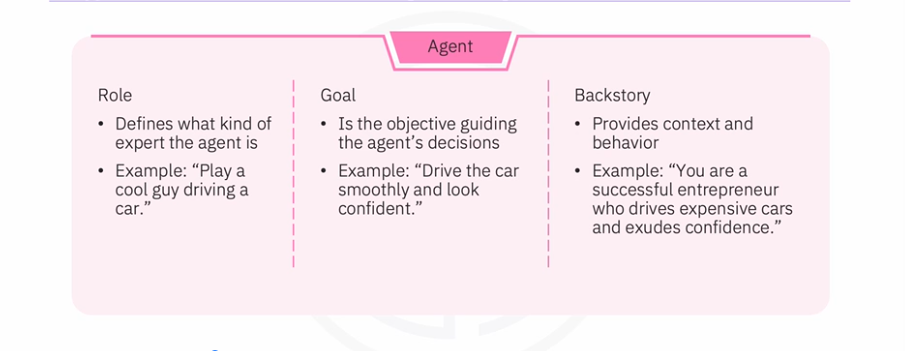

        - Tools
        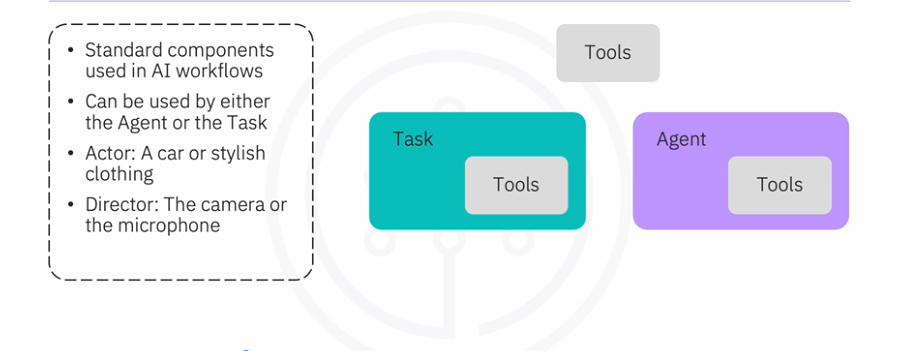

    - the process
        - create an agent
        - define a task (what to do)
        - then define flows into the agent (input and output)
        - flows
            - define how tasks run and how agents interact
            - are set via parameters in the main Crew object
            - One type is sequential
                - output of one task is the input for antoher, it is not input chaining but more like a reflexion chaining
            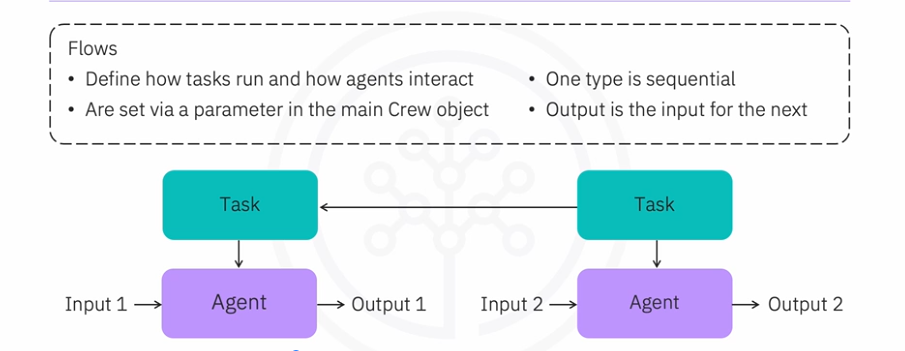
        
        - Heirarchical
        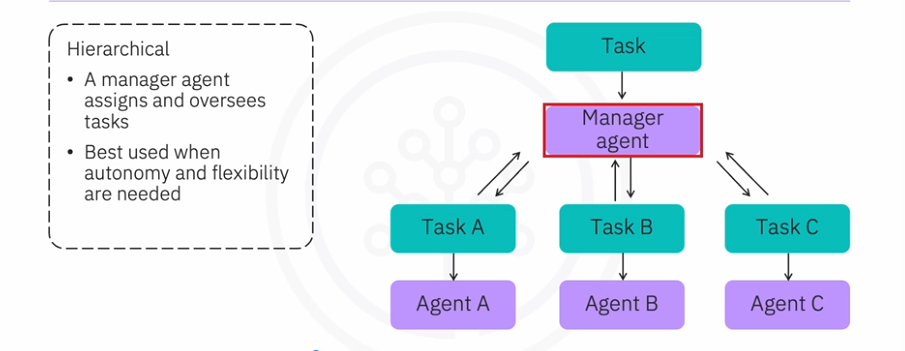
    
    ### Code
    - Initaliye LLM
        - `from crewai import LLM`
    - define Research Agent
    ```python
        from crewai_tools import SerperDevTool
        from crewai import Agent

        search_agent = Agent(
            role = "Senior Research Analyst",
            goal = "...",
            back_story = "...",
            verbose=True,
            allow_delegation=False, # agent perform his task, no delegation
            llm=llm,
            tools=[SerperDevTool()]
        )
    ```
    - define Research Task
    ```python
    from crewai import Task

    research_task = Task(
        description = """Analyze the major {topic}, identify key trends and technologies. Provide a detailed report on their protential impact.""",

        agent=reserch_agent,

        exoected_output = "A detailed report on {topic}, including trends, emerging technologies, and their impact" # success criterien
    )
    ```

    - create multiple agents
        - like "Reseacher Agent", "Writer Agent"
    
    - create Crew Object
    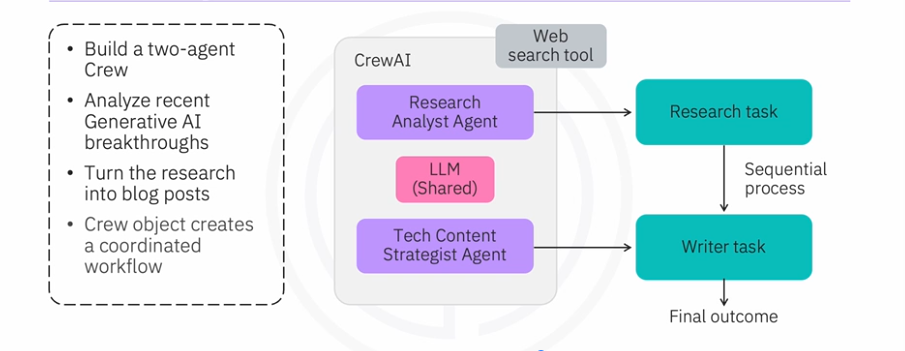
    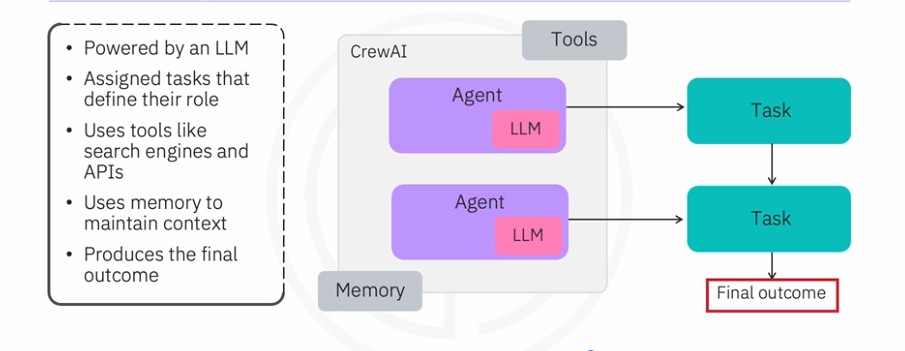

    ```python
    from crewai import Crew, Process

    crew = Crew(
        agents = [research_agent, writer_agent],
        tasks = [research_task, writer_task],
        process = Process.sequential, # define the process flow
        verbose = True
    )
    ```

    - run the crew using .kickoff() 
    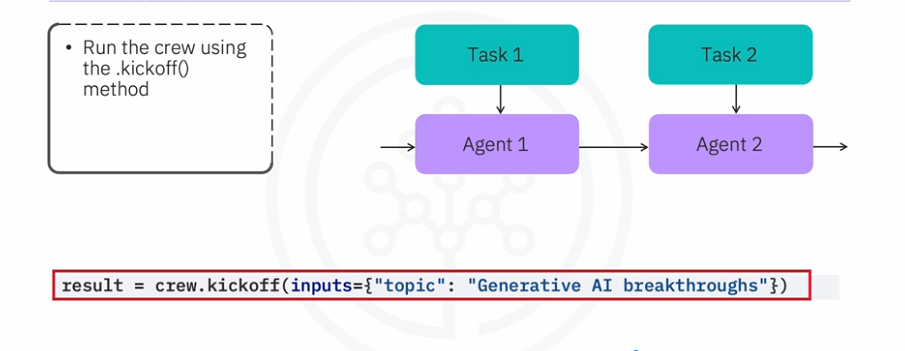

    ```python
    result = crew.kickoff(inputs={"topic": "Generative AI breakthroughs"})
    ```

- Summary
    - Crewai is designed for multi-agent collaboration, with agents assigned clear roles and tasks to simulate human like teamwork
    - A task defines what an agent should do, including a goal, descritpin, and expected output.
    - An Agent is powered by an LLM and duided by structured prompts: rols, goal, and backstory to simulate personality and expertise.
    - Tools like APIs or search engines enhance gent capabilites and can be assigened to both agents and tasks
    - The Crew Object ties agents, tasks, tools and flow togeter into a coordinated system
    - CrewOutput captures the final result, task outputs, and token usage, giving a full snapshot of what was generated and its cost.












## Structured Outputs, YAMIL and CrewBase Classes

#### Structured output
```python
from pydantic import BaseModel, Field
from crewai import Agent, Task, Crew, Process

class MealPlan(BaseModel):
    """Simple meal plan"""
    meal_name: str = Field(description="Name of the meal")
    difficulty_level: str = Field(description="'Easy', 'Medium', 'Hard'")
    servings: int = Field(description="Number of people it serves")
    researched_ingredients: List[str] = Field(description="Ingredients found through research")

# sample agent 
meal_planner = Agent(
    role="Meal Planner & Recipe Researcher",
    goal="Search for optimal recipes and create detailed meal plans",
    backstory="A skilled meal planner who researches the best recipes online, considering dietary needs, cooking skill levels, and budget constraints.",
    tools=[SerperDevTool()],
    llm=llm,
    verbose=False
)

# sample task
meal_planning_task = Task(
    description=(
        "Search for the best '{meal_name}' recipe for {servings} people within a {budget} budget. "
        "Consider dietary restrictions: {dietary_restrictions} and cooking skill level: {cooking_skill}. "
        "Find recipes that match the skill level and provide complete ingredient lists with quantities."
    ),
    expected_output="A detailed meal plan with researched ingredients, quantities, and cooking instructions appropriate for the skill level.",
    agent=meal_planner, 
    output_pydantic=MealPlan, #pydatnit format specified
    output_file="meals.json"
)

from crewai import Crew, Process

meal_planner_crew = Crew(
    agents=[meal_planner],
    tasks=[meal_planning_task],
    process=Process.sequential,  # Ensures tasks are executed in order
    verbose=True
)

# need to specify the input in the format of the pydantic object
# dictionary, with same keys
meal_planner_result = meal_planner_crew.kickoff(
    inputs={
        "meal_name": "Chicken Stir Fry",
        "servings": 4,
        "budget": "$25",                           
        "dietary_restrictions": ["no nuts"],       
        "cooking_skill": "beginner"                
    }
)
print("✅ Single meal planning completed!")
print("📋 Single Meal Results:")
print(meal_planner_result)
```

#### Context dependency
- when one agent uses the output of another task
- consider `Shopping organizer` uses the output of `meal planner` then we specify the depency in the of in the `shopping organizer task`
- Example
```python
shopping_task = Task(
    description=(
        "Organize the ingredients from the '{meal_name}' meal plan into a grocery shopping list. "
        "Group items by store sections and estimate quantities for {servings} people. "
        "Consider dietary restrictions: {dietary_restrictions} and cooking skill: {cooking_skill}. "
        "Stay within budget: {budget}."
    ),
    expected_output="An organized shopping list grouped by store sections with quantities and prices.",
    agent=shopping_organizer,
    context=[meal_planning_task], # the context varible uses to specify the dependency
    # task of the dependent agent
    output_pydantic=GroceryShoppingPlan,
    output_file="shopping_list.json"
)
```
#### YAML agents and tasks
- support yaml configurations for defining
    - Agents
    - Tasks
    - Crew processes
- what can we define
    - Agents: Roles, golas, backstories, tools, verbosity and more
    - Tasks: description, expected_output, agents and dependencies
    - Crew: execution_flow (process = Process.sequential)

- Agent.yaml
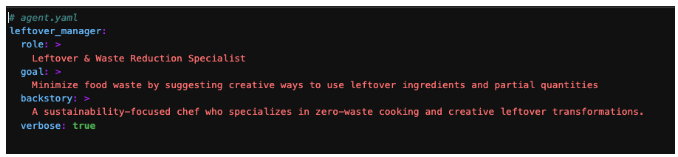
[agents.yaml](./Labs/agents.yaml)

- task.yaml
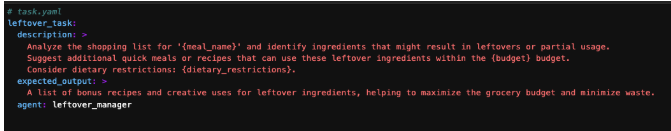
[tasks.yaml](./Labs/tasks.yml)

#### @CrewBase
```python
from crewai.project import CrewBase
from crewai.project.annotations import agent, task

@CrewBase
class myCrew:
    ...

```

#### Decorators overview
- CrewAI provides several decorators that are used to mark methods within your crew class for special handling.

| Decorator           | Marks…                                            |
| :------------------ | :----------------------------------------------- |
| `@CrewBase`         | The class that holds your agents & tasks         |
| `@agent`            | A method that returns an `Agent` object          |
| `@task`             | A method that returns a `Task` object            |
| `@crew`             | (Optional) A method that returns a `Crew` object |
| `@before_kickoff`   | (Optional) Runs once **before** the crew starts  |
| `@after_kickoff`    | (Optional) Runs once **after** the crew finishes |

#### yaml location
- the yaml file should be in `config/` folder

- the yaml file will not work in `Jupyter notebook`. need to use a `.py` file for that

####@CrewBase class
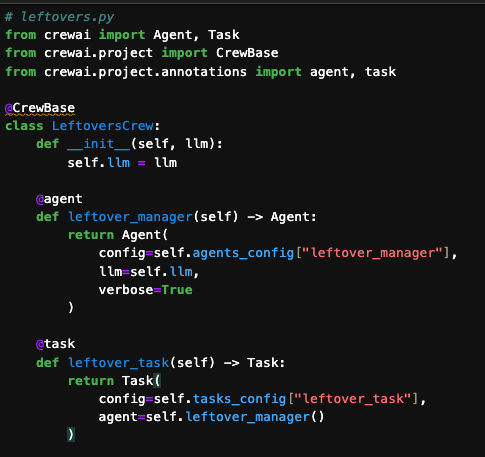

### Summary
- Pydatntic models provide clean, validated data stuctures that agents can pass to one another reliably
- Outputs can be stored in various formats, such as .json for lists and .md for guides depending on task requirements
- YAMIL allows to define agents and tasks outside python, simplifying updates without touching code
- The @CrewBase decorator lods YAMIL-defined components as methods making them easy to call and integrate into a python script or 

[Lab-Notebook](./Labs/Create%20a%20Structured%20Meal%20Grocery%20Planner%20with%20CrewAI.ipynb)



### Custom tools for Agents

- Objectives
    - creating custom functions
    - assigning custom functions to agents and tasks

- custom function
```python
from crewai.tools import tool
import re

@tool("Add Two Number Tool")
def add_numbers(data: str) -> int:
    """
    Extract and adds inteers from the input string.
    Example input: 'add 1 and 2' or '[1, 2, 3,]'
    Output: sum of the numbers
    """
    numbers = list(map(int, re.findall(r'-?/d+', data)))
    return sum(numbers)
```
- the string with the '@tool' is like doc string
- the tool can be assigned to an agent or task as like built in tool
- `tools=[add_numbers]` use the function name to pass the custom tool to the Agent.
- [Lab notebook](./Labs/Agent-Tool%20vs%20Task-Tool%20in%20CrewAI.ipynb)